
# Vertrieb-Reporting – Gruppierung und Clustering von Vermittlern

Dieses Notebook zeigt anhand von **Dummy-Daten**, wie Vermittler für Vertriebsanalysen **gruppiert** werden können.

Es verfolgt zwei Ziele:

1. **Fachliche Gruppierung**  
   Vermittler werden anhand nachvollziehbarer Regeln segmentiert, z. B. nach
   - Schwerpunkt Sach vs. Leben,
   - Aktivitätsniveau,
   - Breite der Veränderungen,
   - Stabilität bzw. Volatilität.

2. **Exploratives Clustering mit Machine Learning**  
   Vermittler werden anhand ihrer Merkmalsprofile automatisch gruppiert, um
   **verborgene Muster** zu erkennen.

Das Notebook enthält:
- Dummy-Daten für mehrere Wochen
- Berechnung von Deltas
- regelbasierte Gruppierung
- Clustering mit **K-Means**
- optional hierarchische Sicht via **Agglomerative Clustering**
- Visualisierung der Gruppen
- Vergleich von Gruppenprofilen
- einen **Appendix** mit weiteren Ideen

> Alle Daten sind künstlich erzeugt und dienen nur der Demonstration der Methodik.


## 0) Imports und Grundkonfiguration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams["figure.dpi"] = 120



## 1) Ausgangsfrage: Ist eine Gruppierung sinnvoll?

Ja, in vielen Fällen ist sie sogar **sehr sinnvoll**.

Denn reine Einzelbetrachtungen je Vermittler beantworten zwar die Frage  
**„Was ist bei Vermittler X passiert?“**,  
aber nicht unbedingt:

- welche **Typen von Vermittlern** es gibt,
- ob sich bestimmte Verhaltensmuster wiederholen,
- welche Vermittler sich ähnlich entwickeln,
- welche Gruppen im Vertrieb gezielt angesprochen werden sollten.

Eine Gruppierung kann daher helfen, von der reinen Beschreibung zur **Steuerung** zu kommen.

### Zwei grundlegende Wege

#### A) Fachlich definierte Gruppen
Hier werden Gruppen anhand nachvollziehbarer Geschäftsregeln gebildet, z. B.:

- eher Sach-getrieben
- eher Leben-getrieben
- breit positiv
- selektiv negativ
- volatil
- stabil

Vorteil:
- leicht verständlich
- fachlich gut kommunizierbar
- gut für Reporting und Management

Nachteil:
- es werden nur Muster gefunden, die man **vorab definiert**

#### B) Clustering mit Machine Learning
Hier werden Gruppen **datengetrieben** gebildet.  
Das Verfahren sucht Vermittler, die sich hinsichtlich ihrer Merkmale ähnlich sind.

Vorteil:
- kann **verborgene Gruppen** finden
- entdeckt Muster, an die man vorher nicht gedacht hat

Nachteil:
- Ergebnisse müssen interpretiert werden
- Gruppen sind nicht automatisch „fachlich sinnvoll“, sondern zunächst nur mathematisch ähnlich

### Praktische Empfehlung
In einem Vertriebsprojekt ist meist die Kombination am stärksten:

- zuerst **fachliche Segmente** für Transparenz und Nachvollziehbarkeit,
- danach **Clustering**, um zusätzliche verborgene Strukturen zu identifizieren.



## 2) Dummy-Daten erzeugen

Wir simulieren mehrere Wochen für Vermittler mit Sach- und Leben-Produkten.  
Dabei bauen wir bewusst unterschiedliche „Vermittler-Typen“ in die Daten ein, damit das Clustering sinnvolle Muster finden kann.


In [2]:
sach_products = ["SV_Hausrat", "SV_Unfall", "SV_BU", "SV_KFZ", "SV_Haftpflicht"]
leben_products = ["LV_Risiko_A", "LV_Risiko_B", "LV_Risiko_C", "LV_Rente"]
all_products = sach_products + leben_products

weeks = pd.date_range("2026-01-05", periods=8, freq="W-MON")

n_brokers = 80
broker_ids = np.arange(1001, 1001 + n_brokers)

broker_types = np.random.choice(
    ["sach_fokus", "leben_fokus", "breit_aktiv", "volatil"],
    size=n_brokers,
    p=[0.30, 0.25, 0.25, 0.20]
)

broker_type_map = pd.DataFrame({
    "vermittler_id": broker_ids,
    "true_type": broker_types
})

def generate_weekly_sales(broker_id, broker_type, week_idx):
    rng = np.random.default_rng(seed=broker_id * 100 + week_idx)
    values = {}

    if broker_type == "sach_fokus":
        for p in sach_products:
            values[p] = max(0, rng.poisson(4) + rng.integers(-1, 2))
        for p in leben_products:
            values[p] = max(0, rng.poisson(1) + rng.integers(-1, 2))

    elif broker_type == "leben_fokus":
        for p in sach_products:
            values[p] = max(0, rng.poisson(1) + rng.integers(-1, 2))
        for p in leben_products:
            values[p] = max(0, rng.poisson(4) + rng.integers(-1, 2))

    elif broker_type == "breit_aktiv":
        for p in all_products:
            values[p] = max(0, rng.poisson(3) + rng.integers(-1, 2))

    elif broker_type == "volatil":
        for p in all_products:
            base = rng.poisson(2)
            shock = rng.integers(-3, 8) if rng.random() < 0.35 else 0
            values[p] = max(0, base + shock)

    return values

rows = []
for week_idx, week in enumerate(weeks):
    for broker_id, btype in zip(broker_ids, broker_types):
        sales = generate_weekly_sales(broker_id, btype, week_idx)
        row = {"week": week, "vermittler_id": broker_id, "true_type": btype}
        row.update(sales)
        rows.append(row)

df_weekly = pd.DataFrame(rows)

print(df_weekly.shape)
display(df_weekly.head())
display(broker_type_map.head())


(640, 12)


,week,vermittler_id,true_type,SV_Hausrat,SV_Unfall,SV_BU,SV_KFZ,SV_Haftpflicht,LV_Risiko_A,LV_Risiko_B,LV_Risiko_C,LV_Rente
0,2026-01-05,1001,leben_fokus,0,0,1,0,1,4,4,5,0
1,2026-01-05,1002,volatil,3,1,2,8,11,1,2,1,1
2,2026-01-05,1003,breit_aktiv,4,6,1,3,4,4,0,2,3
3,2026-01-05,1004,breit_aktiv,5,0,3,5,4,0,1,2,2
4,2026-01-05,1005,sach_fokus,4,0,1,2,5,2,1,0,5


,vermittler_id,true_type
0,1001,leben_fokus
1,1002,volatil
2,1003,breit_aktiv
3,1004,breit_aktiv
4,1005,sach_fokus



## 3) Deltas berechnen

Für das Clustering sind Deltas oft besonders interessant, weil sie die **Veränderung** und nicht nur das Niveau beschreiben.
Hier berechnen wir für jede Woche die Veränderung gegenüber der Vorwoche.


In [3]:
df_weekly = df_weekly.sort_values(["vermittler_id", "week"]).reset_index(drop=True)

for p in all_products:
    df_weekly[f"DELTA_{p}"] = df_weekly.groupby("vermittler_id")[p].diff()

delta_cols = [f"DELTA_{p}" for p in all_products]

display(df_weekly.head(12))


,week,vermittler_id,true_type,SV_Hausrat,SV_Unfall,SV_BU,SV_KFZ,SV_Haftpflicht,LV_Risiko_A,LV_Risiko_B,...,LV_Rente,DELTA_SV_Hausrat,DELTA_SV_Unfall,DELTA_SV_BU,DELTA_SV_KFZ,DELTA_SV_Haftpflicht,DELTA_LV_Risiko_A,DELTA_LV_Risiko_B,DELTA_LV_Risiko_C,DELTA_LV_Rente
0,2026-01-05,1001,leben_fokus,0,0,1,0,1,4,4,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-12,1001,leben_fokus,1,0,1,6,4,3,1,...,2,1.0,0.0,0.0,6.0,3.0,-1.0,-3.0,3.0,2.0
2,2026-01-19,1001,leben_fokus,0,1,1,2,0,5,4,...,2,-1.0,1.0,0.0,-4.0,-4.0,2.0,3.0,-5.0,0.0
3,2026-01-26,1001,leben_fokus,1,1,1,1,3,4,4,...,2,1.0,0.0,0.0,-1.0,3.0,-1.0,0.0,1.0,0.0
4,2026-02-02,1001,leben_fokus,1,0,4,0,0,1,7,...,4,0.0,-1.0,3.0,-1.0,-3.0,-3.0,3.0,0.0,2.0
5,2026-02-09,1001,leben_fokus,4,0,2,0,2,4,3,...,8,3.0,0.0,-2.0,0.0,2.0,3.0,-4.0,0.0,4.0
6,2026-02-16,1001,leben_fokus,1,1,0,0,1,1,4,...,3,-3.0,1.0,-2.0,0.0,-1.0,-3.0,1.0,-1.0,-5.0
7,2026-02-23,1001,leben_fokus,1,0,2,1,0,5,2,...,3,0.0,-1.0,2.0,1.0,-1.0,4.0,-2.0,2.0,0.0
8,2026-01-05,1002,volatil,3,1,2,8,11,1,2,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-01-12,1002,volatil,9,2,1,0,0,3,1,...,1,6.0,1.0,-1.0,-8.0,-11.0,2.0,-1.0,3.0,0.0



## 4) Merkmale für die Gruppierung konstruieren

Ein Clustering sollte nicht direkt auf Rohdaten „blind“ losgelassen werden, sondern auf **sinnvolle Merkmale**.

Hier erzeugen wir je Vermittler Merkmale wie:

- durchschnittliches Sach-Niveau
- durchschnittliches Leben-Niveau
- durchschnittliche Sach-Delta-Bewegung
- durchschnittliche Leben-Delta-Bewegung
- Volatilität der Deltas
- Anzahl positiver Deltas
- Anzahl negativer Deltas
- Breite der Aktivität


In [4]:
df_weekly["SACH_SUM"] = df_weekly[sach_products].sum(axis=1)
df_weekly["LEBEN_SUM"] = df_weekly[leben_products].sum(axis=1)

df_weekly["DELTA_SACH_SUM"] = df_weekly[[f"DELTA_{p}" for p in sach_products]].sum(axis=1, min_count=1)
df_weekly["DELTA_LEBEN_SUM"] = df_weekly[[f"DELTA_{p}" for p in leben_products]].sum(axis=1, min_count=1)

df_weekly["POS_DELTA_COUNT"] = (df_weekly[delta_cols] > 0).sum(axis=1)
df_weekly["NEG_DELTA_COUNT"] = (df_weekly[delta_cols] < 0).sum(axis=1)
df_weekly["ACTIVE_PRODUCT_COUNT"] = (df_weekly[all_products] > 0).sum(axis=1)
df_weekly["ABS_DELTA_TOTAL"] = df_weekly[delta_cols].abs().sum(axis=1)

feature_df = (
    df_weekly.groupby("vermittler_id")
    .agg(
        sach_mean=("SACH_SUM", "mean"),
        leben_mean=("LEBEN_SUM", "mean"),
        sach_delta_mean=("DELTA_SACH_SUM", "mean"),
        leben_delta_mean=("DELTA_LEBEN_SUM", "mean"),
        delta_volatility=("ABS_DELTA_TOTAL", "mean"),
        pos_delta_mean=("POS_DELTA_COUNT", "mean"),
        neg_delta_mean=("NEG_DELTA_COUNT", "mean"),
        active_products_mean=("ACTIVE_PRODUCT_COUNT", "mean"),
        sach_std=("SACH_SUM", "std"),
        leben_std=("LEBEN_SUM", "std"),
    )
    .reset_index()
)

feature_df = feature_df.merge(broker_type_map, on="vermittler_id", how="left")

display(feature_df.head())


,vermittler_id,sach_mean,leben_mean,sach_delta_mean,leben_delta_mean,delta_volatility,pos_delta_mean,neg_delta_mean,active_products_mean,sach_std,leben_std,true_type
0,1001,5.625,14.500,0.285714,0.285714,13.750,3.000,2.875,7.000,3.248626,2.329929,leben_fokus
1,1002,15.000,7.875,-1.714286,0.142857,16.625,2.375,3.250,7.750,5.014265,2.167124,volatil
2,1003,16.750,11.250,0.285714,0.142857,14.625,3.375,3.125,8.375,2.764572,4.496030,breit_aktiv
3,1004,15.375,13.500,0.285714,0.285714,18.250,3.750,3.250,8.250,3.248626,5.580579,breit_aktiv
4,1005,18.250,5.625,1.285714,-0.714286,14.750,3.250,3.125,7.750,4.234214,1.846812,sach_fokus



## 5) Fachliche Gruppierung per Regelwerk

Bevor man Clustering einsetzt, lohnt sich fast immer ein **fachlich nachvollziehbares Regelwerk**.

Das ist besonders dann sinnvoll, wenn Gruppen für Management und Vertrieb **direkt kommunizierbar** sein sollen.


In [5]:
def assign_rule_segment(row):
    if row["sach_mean"] > row["leben_mean"] * 1.5:
        focus = "Sach-Fokus"
    elif row["leben_mean"] > row["sach_mean"] * 1.5:
        focus = "Leben-Fokus"
    else:
        focus = "Gemischt"

    if row["delta_volatility"] > feature_df["delta_volatility"].median() * 1.25:
        dynamic = "volatil"
    else:
        dynamic = "stabil"

    if row["active_products_mean"] >= 7:
        breadth = "breit"
    else:
        breadth = "selektiv"

    return f"{focus} | {dynamic} | {breadth}"

feature_df["rule_segment"] = feature_df.apply(assign_rule_segment, axis=1)

display(feature_df[["vermittler_id", "true_type", "rule_segment"]].head(12))
print(feature_df["rule_segment"].value_counts())


,vermittler_id,true_type,rule_segment
0,1001,leben_fokus,Leben-Fokus | stabil | breit
1,1002,volatil,Sach-Fokus | stabil | breit
2,1003,breit_aktiv,Gemischt | stabil | breit
3,1004,breit_aktiv,Gemischt | stabil | breit
4,1005,sach_fokus,Sach-Fokus | stabil | breit
5,1006,sach_fokus,Sach-Fokus | stabil | selektiv
6,1007,sach_fokus,Sach-Fokus | stabil | breit
7,1008,volatil,Gemischt | volatil | breit
8,1009,breit_aktiv,Gemischt | stabil | breit
9,1010,breit_aktiv,Gemischt | stabil | breit


rule_segment
Sach-Fokus | stabil | breit        24
Gemischt | stabil | breit          17
Leben-Fokus | stabil | breit       13
Sach-Fokus | stabil | selektiv      9
Gemischt | volatil | breit          7
Leben-Fokus | stabil | selektiv     5
Sach-Fokus | volatil | breit        4
Gemischt | volatil | selektiv       1
Name: count, dtype: int64



### Interpretation

Diese regelbasierte Gruppierung hat einen großen Vorteil:

- sie ist **fachlich begründbar**
- sie ist **stabil kommunizierbar**
- sie eignet sich gut für Reporting, Steuerung und Präsentation

Sie ist aber nicht der „Gold-Standard“ für verborgene Muster, weil sie nur das findet, was im Regelwerk **vorab angelegt** wurde.



## 6) Clustering mit Machine Learning

Um verborgene Gruppen zu finden, kann man ein Clustering-Verfahren verwenden.

### Welches Verfahren ist hier geeignet?

Für einen ersten Prototyp sind besonders sinnvoll:

#### A) K-Means
- einfach
- schnell
- gut interpretierbar
- geeignet für numerische Merkmale

#### B) Agglomerative Clustering
- hierarchischer Ansatz
- oft hilfreich, wenn man Gruppen nicht nur flach, sondern verschachtelt betrachten möchte

### Was ist hier für den Einstieg am sinnvollsten?

Für einen ersten Prototypen ist **K-Means** meist die beste Wahl, weil:
- es leicht erklärbar ist,
- schnell läuft,
- und gute erste Ergebnisse liefert.

Wichtig ist aber: Die Merkmale müssen vorher **standardisiert** werden.


In [6]:
cluster_features = [
    "sach_mean",
    "leben_mean",
    "sach_delta_mean",
    "leben_delta_mean",
    "delta_volatility",
    "pos_delta_mean",
    "neg_delta_mean",
    "active_products_mean",
    "sach_std",
    "leben_std",
]

X = feature_df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)


(80, 10)



## 7) Wahl der Clusterzahl

Die Clusterzahl ist nicht „automatisch wahr“.  
Man muss sie prüfen und interpretieren.

Hier verwenden wir zwei einfache Hilfen:

- **Inertia** (Elbow-Idee)
- **Silhouette Score**


c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

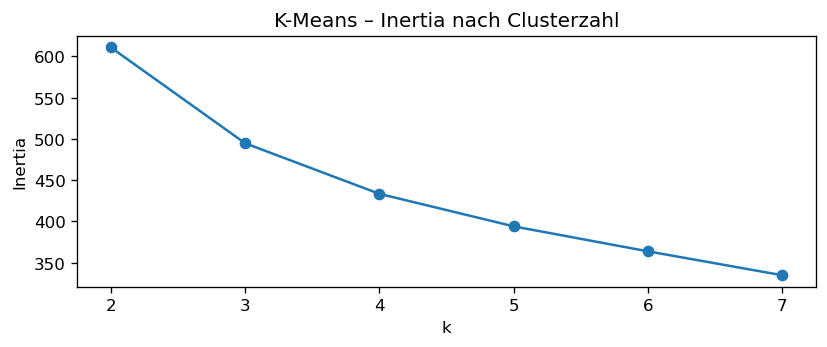

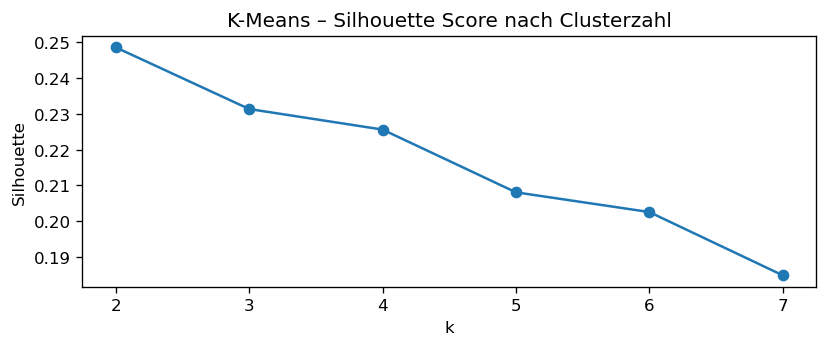

,k,inertia,silhouette
0,2,610.765464,0.248456
1,3,494.679999,0.231287
2,4,433.384863,0.225562
3,5,394.003414,0.208083
4,6,363.745835,0.202587
5,7,334.773505,0.184971


In [7]:
k_values = range(2, 8)
inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 3))
plt.plot(list(k_values), inertias, marker="o")
plt.title("K-Means – Inertia nach Clusterzahl")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("K-Means – Silhouette Score nach Clusterzahl")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

display(pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes}))



## 8) K-Means anwenden

Im Prototyp wählen wir hier beispielhaft **k = 4**.  
In echten Daten sollte diese Wahl fachlich und analytisch geprüft werden.


In [8]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
feature_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

display(feature_df[["vermittler_id", "true_type", "rule_segment", "kmeans_cluster"]].head(15))
print(feature_df["kmeans_cluster"].value_counts().sort_index())


c:\Users\stefa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,vermittler_id,true_type,rule_segment,kmeans_cluster
0,1001,leben_fokus,Leben-Fokus | stabil | breit,1
1,1002,volatil,Sach-Fokus | stabil | breit,3
2,1003,breit_aktiv,Gemischt | stabil | breit,0
3,1004,breit_aktiv,Gemischt | stabil | breit,0
4,1005,sach_fokus,Sach-Fokus | stabil | breit,3
5,1006,sach_fokus,Sach-Fokus | stabil | selektiv,3
6,1007,sach_fokus,Sach-Fokus | stabil | breit,3
7,1008,volatil,Gemischt | volatil | breit,2
8,1009,breit_aktiv,Gemischt | stabil | breit,0
9,1010,breit_aktiv,Gemischt | stabil | breit,0


kmeans_cluster
0    19
1    18
2    14
3    29
Name: count, dtype: int64



## 9) Cluster in 2D visualisieren (PCA)

Da wir viele Merkmale haben, projizieren wir die Vermittler für die Visualisierung auf zwei Hauptkomponenten.
Wichtig: Die Projektion dient nur der **Visualisierung**, nicht der eigentlichen Clusterbildung.


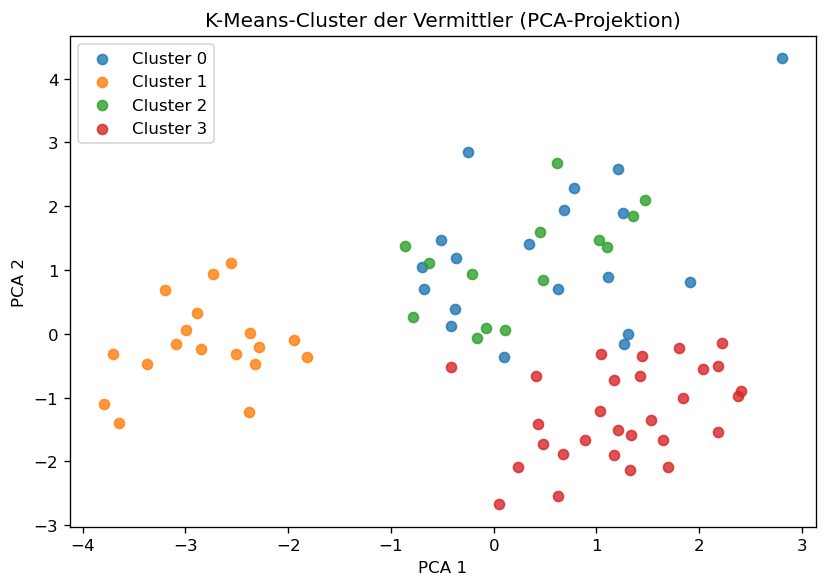

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

feature_df["pca1"] = X_pca[:, 0]
feature_df["pca2"] = X_pca[:, 1]

plt.figure(figsize=(7, 5))
for cluster_id in sorted(feature_df["kmeans_cluster"].unique()):
    sub = feature_df[feature_df["kmeans_cluster"] == cluster_id]
    plt.scatter(sub["pca1"], sub["pca2"], label=f"Cluster {cluster_id}", alpha=0.8)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means-Cluster der Vermittler (PCA-Projektion)")
plt.legend()
plt.tight_layout()
plt.show()



## 10) Clusterprofile interpretieren

Ein Cluster ist erst dann nützlich, wenn man sein Profil versteht.  
Daher berechnen wir die Mittelwerte der Merkmale je Cluster.


In [10]:
cluster_profile = feature_df.groupby("kmeans_cluster")[cluster_features].mean().round(2)
display(cluster_profile)

true_type_vs_cluster = pd.crosstab(feature_df["true_type"], feature_df["kmeans_cluster"])
display(true_type_vs_cluster)

rule_segment_vs_cluster = pd.crosstab(feature_df["rule_segment"], feature_df["kmeans_cluster"])
display(rule_segment_vs_cluster)


,sach_mean,leben_mean,sach_delta_mean,leben_delta_mean,delta_volatility,pos_delta_mean,neg_delta_mean,active_products_mean,sach_std,leben_std
kmeans_cluster,,,,,,,,,,
0,16.11,10.67,0.68,0.17,16.28,3.48,3.06,8.23,4.26,3.43
1,5.57,15.71,0.00,-0.16,12.75,2.87,3.04,6.98,2.49,4.03
2,14.05,11.30,-0.76,-0.30,19.78,3.14,3.46,7.78,4.78,4.08
3,19.69,4.63,-0.15,-0.12,15.09,3.03,3.19,7.25,4.62,2.15


kmeans_cluster,0,1,2,3
true_type,,,,
breit_aktiv,11,0,5,0
leben_fokus,0,18,0,0
sach_fokus,3,0,0,27
volatil,5,0,9,2


kmeans_cluster,0,1,2,3
rule_segment,,,,
Gemischt | stabil | breit,11,0,6,0
Gemischt | volatil | breit,2,0,5,0
Gemischt | volatil | selektiv,0,0,1,0
Leben-Fokus | stabil | breit,0,13,0,0
Leben-Fokus | stabil | selektiv,0,5,0,0
Sach-Fokus | stabil | breit,5,0,0,19
Sach-Fokus | stabil | selektiv,0,0,0,9
Sach-Fokus | volatil | breit,1,0,2,1



### Was man hier typischerweise sucht

- Cluster mit hohem **Sach-Niveau**
- Cluster mit hohem **Leben-Niveau**
- Cluster mit hoher **Volatilität**
- Cluster mit breiter oder selektiver Produktaktivität

Erst aus diesem Profil bekommt das Clustering einen vertrieblichen Sinn.

### Wichtiger Hinweis
Clustering liefert zunächst **mathematische Gruppen**, keine automatisch „wahren“ Geschäftsgruppen.  
Die fachliche Interpretation ist deshalb zwingend notwendig.



## 11) Alternative: Agglomerative Clustering

Zusätzlich kann ein hierarchisches Verfahren ausprobiert werden.  
Das ist nützlich, wenn man eine alternative Gruppensicht möchte.


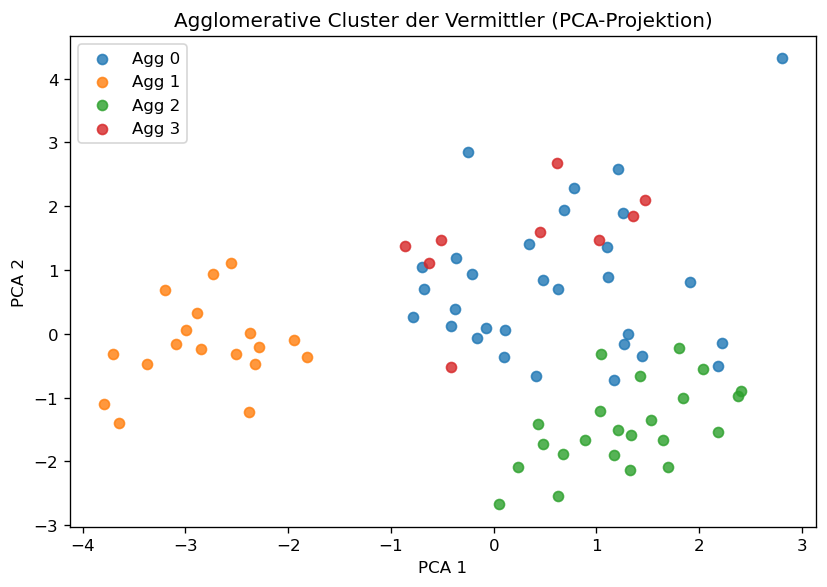

kmeans_cluster,0,1,2,3
agg_cluster,,,,
0,18,0,7,5
1,0,18,0,0
2,0,0,0,23
3,1,0,7,1


In [11]:
agg = AgglomerativeClustering(n_clusters=4)
feature_df["agg_cluster"] = agg.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
for cluster_id in sorted(feature_df["agg_cluster"].unique()):
    sub = feature_df[feature_df["agg_cluster"] == cluster_id]
    plt.scatter(sub["pca1"], sub["pca2"], label=f"Agg {cluster_id}", alpha=0.8)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Agglomerative Cluster der Vermittler (PCA-Projektion)")
plt.legend()
plt.tight_layout()
plt.show()

display(pd.crosstab(feature_df["agg_cluster"], feature_df["kmeans_cluster"]))



## 12) Gruppenbasierte Auswertungen

Wenn Vermittler gruppiert sind, können die bisherigen Auswertungen **auch auf Gruppenebene** gemacht werden.

Beispiele:
- Durchschnittsdeltas je Gruppe
- Volatilität je Gruppe
- Produktprofile je Gruppe
- Top/Flop-Produkte je Gruppe


In [12]:
delta_long = df_weekly.melt(
    id_vars=["week", "vermittler_id", "true_type"],
    value_vars=delta_cols,
    var_name="produkt",
    value_name="delta"
)

delta_long["produkt"] = delta_long["produkt"].str.replace("DELTA_", "", regex=False)
delta_long = delta_long.merge(
    feature_df[["vermittler_id", "rule_segment", "kmeans_cluster", "agg_cluster"]],
    on="vermittler_id",
    how="left"
)

delta_long["delta"] = pd.to_numeric(delta_long["delta"], errors="coerce")

display(delta_long.head())


,week,vermittler_id,true_type,produkt,delta,rule_segment,kmeans_cluster,agg_cluster
0,2026-01-05,1001,leben_fokus,SV_Hausrat,NaN,Leben-Fokus | stabil | breit,1,1
1,2026-01-12,1001,leben_fokus,SV_Hausrat,1.0,Leben-Fokus | stabil | breit,1,1
2,2026-01-19,1001,leben_fokus,SV_Hausrat,-1.0,Leben-Fokus | stabil | breit,1,1
3,2026-01-26,1001,leben_fokus,SV_Hausrat,1.0,Leben-Fokus | stabil | breit,1,1
4,2026-02-02,1001,leben_fokus,SV_Hausrat,0.0,Leben-Fokus | stabil | breit,1,1


produkt,LV_Rente,LV_Risiko_A,LV_Risiko_B,LV_Risiko_C,SV_BU,SV_Haftpflicht,SV_Hausrat,SV_KFZ,SV_Unfall
kmeans_cluster,,,,,,,,,
0,-0.10,0.06,0.08,0.12,0.26,0.15,0.00,0.11,0.17
1,-0.02,-0.09,0.03,-0.09,-0.02,0.04,-0.06,0.02,0.02
2,-0.10,-0.05,-0.09,-0.05,-0.05,-0.14,-0.33,-0.05,-0.18
3,-0.05,-0.07,0.00,0.00,0.05,0.00,-0.06,-0.14,-0.00


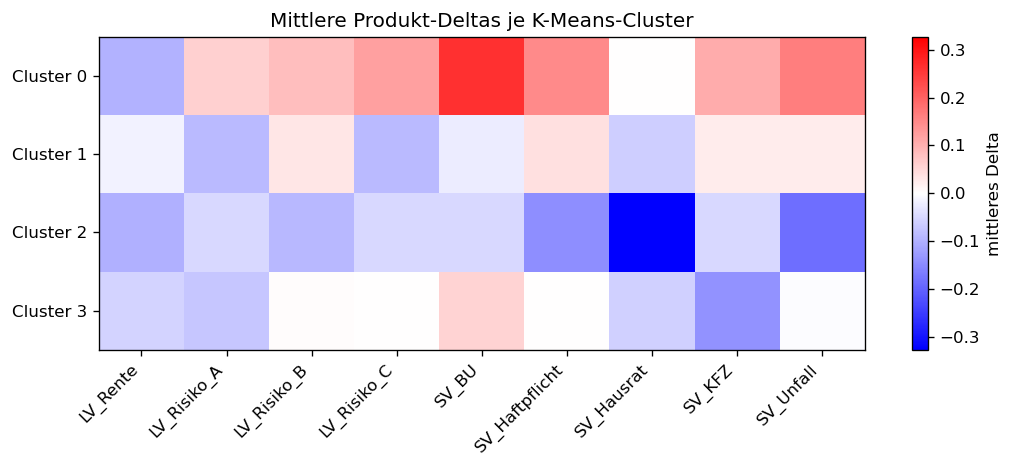

In [13]:
cluster_product_profile = (
    delta_long.groupby(["kmeans_cluster", "produkt"])["delta"]
    .mean()
    .reset_index()
)

pivot_cluster_product = cluster_product_profile.pivot(
    index="kmeans_cluster",
    columns="produkt",
    values="delta"
).fillna(0)

display(pivot_cluster_product.round(2))

plt.figure(figsize=(9, 4))
plt.imshow(
    pivot_cluster_product.values,
    aspect="auto",
    cmap="bwr",
    vmin=-np.abs(pivot_cluster_product.values).max(),
    vmax=np.abs(pivot_cluster_product.values).max()
)
plt.colorbar(label="mittleres Delta")
plt.xticks(range(len(pivot_cluster_product.columns)), pivot_cluster_product.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_cluster_product.index)), [f"Cluster {i}" for i in pivot_cluster_product.index])
plt.title("Mittlere Produkt-Deltas je K-Means-Cluster")
plt.tight_layout()
plt.show()


## 13) Beispiel: Gruppenranking nach Volatilität und Aktivität

In [14]:
group_summary = (
    feature_df.groupby("kmeans_cluster")
    .agg(
        vermittler_anzahl=("vermittler_id", "count"),
        sach_mean=("sach_mean", "mean"),
        leben_mean=("leben_mean", "mean"),
        delta_volatility=("delta_volatility", "mean"),
        active_products_mean=("active_products_mean", "mean"),
    )
    .round(2)
    .sort_values("delta_volatility", ascending=False)
)

display(group_summary)


,vermittler_anzahl,sach_mean,leben_mean,delta_volatility,active_products_mean
kmeans_cluster,,,,,
2,14,14.05,11.30,19.78,7.78
0,19,16.11,10.67,16.28,8.23
3,29,19.69,4.63,15.09,7.25
1,18,5.57,15.71,12.75,6.98



## 14) Fazit: Was ist sinnvoll?

### Fachlich definierte Gruppen sind sinnvoll, wenn:
- Gruppen klar kommunizierbar sein sollen
- Management und Vertrieb nachvollziehbare Logik brauchen
- das Reporting stabil und wiederholbar sein soll

### Clustering ist sinnvoll, wenn:
- verborgene Muster gesucht werden
- ähnliche Vermittler automatisch gefunden werden sollen
- die Segmentierung explorativ weiterentwickelt werden soll

### Praktisch stärkster Ansatz
Am stärksten ist meist:

1. **fachliche Segmentierung als Basis**
2. **Clustering als explorative Ergänzung**
3. **Interpretation der Cluster mit Fachsicht**

Genau diese Kombination ist oft der realistische „Gold-Standard“.


# Appendix I  – Weitere Ideen und mögliche Ausbaustufen


## A) Weitere mögliche Clustering-Verfahren

Neben K-Means und Agglomerative Clustering kommen je nach Daten auch in Frage:

- **Gaussian Mixture Models**  
  wenn Cluster eher probabilistisch interpretiert werden sollen

- **DBSCAN / HDBSCAN**  
  wenn Ausreißer und unregelmäßige Clusterformen besonders wichtig sind

- **Spectral Clustering**  
  wenn komplexere Strukturen vermutet werden

Für einen ersten Prototypen ist K-Means aber fast immer der sinnvollste Startpunkt.



## B) Bessere Merkmalskonstruktion

Die Qualität des Clusterings hängt stark von den gewählten Merkmalen ab.  
Später könnten z. B. ergänzt werden:

- Netto- vs. Bruttobewegung
- Anteil positiver zu negativer Deltas
- Produktanteile
- Rollierende Mittelwerte
- Trendstärke über mehrere Wochen
- Saisonalität
- Verhältnis Sach zu Leben



## C) Clustering auf unterschiedlichen Ebenen

Man kann nicht nur Vermittler, sondern auch andere Einheiten clustern:

- Produkte
- Regionen
- Vertriebsgruppen
- Wochen bzw. Zeiträume
- Vermittler × Produkt-Profile



## D) Zeitreihenorientierte Erweiterung

Sobald mehr Wochen vorliegen, kann man stärker zeitbezogen segmentieren:

- stabile Wachstumsprofile
- volatile Vermittler
- saisonale Muster
- Breaks / Strukturbrüche
- Frühwarnindikatoren



## E) Kombination mit fachlichen Labels

Eine sehr starke Praxislösung besteht darin,

- fachlich definierte Segmente als Basis zu verwenden
- und Clustering nur als zweite zusätzliche Sicht einzusetzen

Dann kann man prüfen:

- bestätigt das Clustering die Fachlogik?
- zeigt es neue Gruppen?
- wo weichen beide Sichtweisen voneinander ab?



## F) Mögliche nächste Prototypen

Ein nächster Schritt könnte ein weiteres Notebook sein mit:

1. echten Excel-Dateien
2. Feature-Engineering auf euren Originalspalten
3. Clusterprofilen für Sach und Leben getrennt
4. gruppenbasierten Heatmaps
5. interaktiven Grafiken
6. Export als HTML oder Streamlit-App


# Appendix II  – ausführliche(ere) Erklärungen

## zu 4) Merkmale für die Gruppierung konstruieren

Ein Clustering sollte nicht direkt auf den Rohdaten durchgeführt werden, sondern auf **aussagekräftigen Merkmalen**. Der Grund dafür ist, dass Rohdaten zwar viele Einzelinformationen enthalten, aber noch keine gut interpretierbare Struktur für die Bildung von Gruppen liefern.

Im vorliegenden Fall bestehen die Rohdaten zunächst aus Absatzzahlen je Vermittler, Produkt und Woche. Würde man ein Clustering direkt auf diesen Einzelwerten ansetzen, dann würden sich zwar mathematisch Gruppen bilden, diese wären aber fachlich oft nur schwer zu deuten. Für eine vertriebliche Interpretation ist es deshalb sinnvoll, die Rohdaten zunächst in **verdichtete beschreibende Kennzahlen** zu überführen.

Diese Kennzahlen bezeichnen wir hier als **Merkmale**. Sie fassen das Verhalten eines Vermittlers in kompakter Form zusammen und machen damit typische Muster sichtbar.

### Ziel der Merkmalsbildung

Die Merkmalsbildung verfolgt das Ziel, je Vermittler ein Profil zu erzeugen, das insbesondere folgende Fragen beantwortet:

- Liegt der Schwerpunkt eher auf Sach oder eher auf Leben?
- Ist ein Vermittler insgesamt eher aktiv oder eher zurückhaltend?
- Verändert sich das Geschäft eher stabil oder eher sprunghaft?
- Treten Veränderungen breit über viele Produkte hinweg auf oder nur punktuell?
- Überwiegen eher positive oder eher negative Wochenbewegungen?

Erst solche zusammenfassenden Merkmale ermöglichen ein Clustering, das auch fachlich sinnvoll interpretiert werden kann.

---

### Verwendete Merkmale im Notebook

#### 1. Durchschnittliches Sach-Niveau

Dieses Merkmal misst, wie hoch das durchschnittliche Absatzniveau eines Vermittlers im Bereich Sach über die betrachteten Wochen hinweg ist.

Es wird berechnet, indem die Sach-Produkte je Woche aufsummiert und anschließend über die Wochen gemittelt werden.

**Interpretation:**  
Ein hoher Wert spricht dafür, dass der Vermittler im Bereich Sach insgesamt stark aktiv ist.  
Das Merkmal hilft insbesondere dabei, Vermittler mit **Sach-Schwerpunkt** zu identifizieren.

---

#### 2. Durchschnittliches Leben-Niveau

Analog dazu misst dieses Merkmal das durchschnittliche Absatzniveau eines Vermittlers im Bereich Leben.

Auch hier werden zunächst die Leben-Produkte je Woche aufsummiert und anschließend über alle Wochen gemittelt.

**Interpretation:**  
Ein hoher Wert deutet auf eine stärkere Aktivität im Bereich Leben hin.  
Im Zusammenspiel mit dem Sach-Niveau lässt sich erkennen, ob ein Vermittler eher **Sach-getrieben**, **Leben-getrieben** oder **gemischt** ist.

---

#### 3. Durchschnittliche Sach-Delta-Bewegung

Hier wird betrachtet, wie sich die Sach-Absätze eines Vermittlers von Woche zu Woche verändern. Dazu werden zunächst die Deltas im Bereich Sach gebildet und diese dann über die Zeit gemittelt.

**Interpretation:**  
Ein positiver Wert deutet darauf hin, dass der Vermittler im Bereich Sach im Durchschnitt eher wächst.  
Ein negativer Wert spricht für einen tendenziellen Rückgang.  
Ein Wert nahe null bedeutet, dass sich positive und negative Bewegungen ungefähr ausgleichen.

Dieses Merkmal beschreibt also nicht das Niveau, sondern die **mittlere Dynamik**.

---

#### 4. Durchschnittliche Leben-Delta-Bewegung

Dieses Merkmal entspricht der Sach-Delta-Bewegung, jedoch für den Bereich Leben.

**Interpretation:**  
Es zeigt, ob sich das Leben-Geschäft eines Vermittlers im Beobachtungszeitraum im Durchschnitt eher positiv, negativ oder neutral entwickelt.

Gerade in Kombination mit dem durchschnittlichen Leben-Niveau kann man unterscheiden zwischen:

- hohem Niveau, aber stagnierendem Geschäft,
- niedrigem Niveau, aber wachsendem Geschäft,
- hohem Niveau und gleichzeitig positiver Entwicklung.

---

#### 5. Volatilität der Deltas

Die Volatilität misst, wie stark die Wochenveränderungen eines Vermittlers insgesamt schwanken. Im Notebook wird dies vereinfacht über die durchschnittliche absolute Delta-Bewegung abgebildet.

Das bedeutet:
- Große positive und große negative Ausschläge erhöhen die Volatilität.
- Gleichmäßige kleine Veränderungen führen zu einer geringeren Volatilität.

**Interpretation:**  
Ein hoher Wert deutet auf ein eher **unruhiges**, schwankendes Vermittlerprofil hin.  
Ein niedriger Wert spricht für ein **stabiles** Verhalten.

Dieses Merkmal ist besonders wichtig, weil zwei Vermittler denselben Mittelwert haben können, sich aber in ihrer Stabilität stark unterscheiden.

---

#### 6. Anzahl positiver Deltas

Hier wird gezählt, in wie vielen Produkten bzw. Wochen positive Veränderungen auftreten.

**Interpretation:**  
Ein hoher Wert bedeutet, dass bei diesem Vermittler häufig Zuwächse auftreten.  
Das kann ein Hinweis auf eine insgesamt positive Entwicklung oder auf eine breite Aktivierung mehrerer Produkte sein.

Dieses Merkmal ergänzt die mittlere Delta-Bewegung, weil es nicht nur die Stärke, sondern auch die **Häufigkeit positiver Bewegungen** berücksichtigt.

---

#### 7. Anzahl negativer Deltas

Entsprechend dazu wird gezählt, wie häufig negative Veränderungen auftreten.

**Interpretation:**  
Ein hoher Wert weist darauf hin, dass Rückgänge vergleichsweise oft vorkommen.  
Das kann ein Indikator für rückläufige Entwicklung, instabiles Geschäft oder ein selektiv schwächeres Produktprofil sein.

Auch dieses Merkmal ergänzt die bloße Durchschnittsbetrachtung, da häufige kleine Rückgänge etwas anderes bedeuten können als wenige starke Rückgänge.

---

#### 8. Breite der Aktivität

Dieses Merkmal beschreibt, über wie viele Produkte ein Vermittler aktiv ist. Im Notebook wird dies vereinfacht über die Zahl der Produkte mit positiven Absatzwerten pro Woche und deren Mittelwert über die Zeit erfasst.

**Interpretation:**  
Ein hoher Wert bedeutet, dass der Vermittler über viele Produkte hinweg aktiv ist.  
Ein niedriger Wert deutet eher auf ein selektives oder spezialisiertes Vermittlerprofil hin.

Damit lässt sich unterscheiden zwischen:

- **breit aufgestellten Vermittlern**, die in vielen Produktbereichen aktiv sind,
- und **selektiven Vermittlern**, deren Geschäft sich auf wenige Produkte konzentriert.

---

### Warum sind diese Merkmale für das Clustering geeignet?

Die ausgewählten Merkmale bilden gemeinsam drei zentrale Dimensionen eines Vermittlerprofils ab:

1. **Niveau**  
   Wie stark ist der Vermittler grundsätzlich im Sach- bzw. Leben-Geschäft?

2. **Dynamik**  
   Wie entwickeln sich die Geschäfte über die Zeit?

3. **Struktur**  
   Wie breit, stabil oder volatil ist das Vertriebsverhalten?

Damit entsteht pro Vermittler kein bloßer Rohdatenvektor, sondern ein fachlich interpretierbares Profil. Genau das ist für Clustering wichtig: Gruppen sollen nicht nur rechnerisch entstehen, sondern später auch verständlich beschrieben werden können.

---

### Warum nicht direkt die Rohdaten verwenden?

Ein direktes Clustering auf Rohdaten hätte mehrere Nachteile:

- Die Daten wären sehr fein granular und schwer interpretierbar.
- Einzelne Wochen oder Produkte könnten das Ergebnis unverhältnismäßig stark beeinflussen.
- Es wäre schwieriger, die gefundenen Cluster fachlich zu benennen.

Die Merkmalsbildung reduziert diese Komplexität und schafft eine Grundlage, auf der Cluster später beispielsweise als

- „Sach-fokussiert und stabil“,
- „Leben-stark und wachsend“,
- „breit aktiv, aber volatil“

interpretiert werden können.

---

### Zusammenfassung

Die Konstruktion von Merkmalen ist ein zentraler Zwischenschritt zwischen Rohdaten und Clustering. Sie übersetzt die vielen Einzelbeobachtungen in ein kompaktes, verständliches Profil je Vermittler. Dadurch wird es möglich, Gruppen nicht nur mathematisch zu bilden, sondern diese später auch fachlich sinnvoll zu interpretieren und für die Vertriebssteuerung nutzbar zu machen.

## zu 5) Fachliche Gruppierung per Regelwerk

Bevor ein datengetriebenes Clustering eingesetzt wird, lohnt sich in vielen Fällen zunächst eine **fachliche Gruppierung per Regelwerk**. Darunter versteht man eine Segmentierung, bei der die Zugehörigkeit zu einer Gruppe nicht durch ein Machine-Learning-Verfahren, sondern durch **bewusst definierte Regeln** festgelegt wird.

Im Unterschied zum Clustering entsteht die Gruppierung hier also **nicht automatisch aus den Daten**, sondern wird durch fachliche Überlegungen gesteuert.

### Grundidee

Die Grundidee ist einfach:

- Es werden Merkmale je Vermittler berechnet.
- Auf Basis dieser Merkmale werden nachvollziehbare Entscheidungsregeln formuliert.
- Aus diesen Regeln werden Gruppen oder Segmente gebildet.

Im Notebook geschieht dies anhand von drei Dimensionen:

1. **Fokus**: Liegt der Vermittler eher im Bereich Sach, eher im Bereich Leben oder ist er gemischt?
2. **Dynamik/Stabilität**: Ist das Verhalten eher volatil oder eher stabil?
3. **Breite der Aktivität**: Ist der Vermittler breit über viele Produkte aktiv oder eher selektiv?

Die Kombination dieser Dimensionen ergibt dann ein Segment wie zum Beispiel:

- `Sach-Fokus | stabil | breit`
- `Leben-Fokus | volatil | selektiv`
- `Gemischt | stabil | breit`

---

### Warum ist eine fachliche Gruppierung sinnvoll?

Eine regelbasierte Gruppierung hat mehrere Vorteile.

#### 1. Hohe Nachvollziehbarkeit

Die Regeln sind offen sichtbar und inhaltlich begründbar. Dadurch lässt sich jederzeit erklären, warum ein Vermittler einem bestimmten Segment zugeordnet wurde.

Beispiel:

- Wenn das durchschnittliche Sach-Niveau deutlich höher ist als das Leben-Niveau, wird der Vermittler als **Sach-Fokus** eingestuft.
- Wenn die Volatilität über einem bestimmten Schwellenwert liegt, gilt der Vermittler als **volatil**.
- Wenn er in vielen Produkten aktiv ist, wird er als **breit** klassifiziert.

Diese Logik ist transparent und für Fachbereiche leicht verständlich.

---

#### 2. Gute Kommunizierbarkeit

Im Reporting und im Management-Kontext ist es oft wichtig, Gruppen so zu definieren, dass sie unmittelbar verständlich sind.

Eine Aussage wie

> „Dieser Vermittler gehört zum Segment Sach-Fokus | stabil | breit“

ist meist leichter zu vermitteln als

> „Dieser Vermittler liegt in Cluster 2 eines K-Means-Modells“.

Gerade in frühen Prototypen ist diese Verständlichkeit ein großer Vorteil.

---

#### 3. Hohe fachliche Kontrolle

Bei regelbasierten Segmenten entscheidet die Fachseite selbst, **welche Eigenschaften überhaupt relevant sind** und **wie stark sie gewichtet werden**.

Damit ist die Methode besonders geeignet, wenn bereits fachliche Hypothesen vorhanden sind, zum Beispiel:

- Vermittler mit starkem Sach-Schwerpunkt verhalten sich typischerweise anders als Vermittler mit Leben-Schwerpunkt.
- Sehr volatile Vermittler sollten gesondert betrachtet werden.
- Breit aktive Vermittler sind vertrieblich anders zu steuern als spezialisierte Vermittler.

---

### Wie funktioniert die Regelbildung konkret?

Im Notebook wird je Vermittler ein Segment in drei Schritten bestimmt.

---

#### A) Fokus: Sach-Fokus, Leben-Fokus oder Gemischt

Zunächst wird geprüft, ob der Vermittler im Durchschnitt stärker im Bereich Sach oder Leben aktiv ist.

Die Logik lautet sinngemäß:

- Ist das Sach-Niveau deutlich größer als das Leben-Niveau, dann: **Sach-Fokus**
- Ist das Leben-Niveau deutlich größer als das Sach-Niveau, dann: **Leben-Fokus**
- Andernfalls: **Gemischt**

Hier wird also nicht einfach nur verglichen, welcher Wert größer ist, sondern ob ein Bereich **deutlich dominiert**. Dadurch wird verhindert, dass schon kleine Unterschiede sofort zu einer harten Zuordnung führen.

**Interpretation:**  
Dieses Merkmal beschreibt den inhaltlichen Schwerpunkt des Vermittlers.

---

#### B) Dynamik: volatil oder stabil

Im zweiten Schritt wird betrachtet, wie stark die Bewegungen im Zeitverlauf schwanken. Dafür wird die Volatilität der Deltas genutzt.

Die Logik lautet vereinfacht:

- Liegt die Volatilität deutlich über dem typischen Niveau, dann: **volatil**
- Andernfalls: **stabil**

Im Notebook wird dabei der Median der Volatilität als Referenz verwendet. Das ist sinnvoll, weil der Median robuster gegenüber Ausreißern ist als der Mittelwert.

**Interpretation:**  
Ein volatiler Vermittler zeigt stärkere oder häufigere Bewegungen, während ein stabiler Vermittler eher gleichmäßig arbeitet.

---

#### C) Breite: breit oder selektiv

Im dritten Schritt wird bewertet, über wie viele Produkte ein Vermittler typischerweise aktiv ist.

Die Logik ist hier:

- Ist die durchschnittliche Zahl aktiver Produkte hoch, dann: **breit**
- Andernfalls: **selektiv**

**Interpretation:**  
Ein breit aktiver Vermittler arbeitet über viele Produkte hinweg, während ein selektiver Vermittler eher spezialisiert ist.

---

### Warum werden diese drei Dimensionen kombiniert?

Jede einzelne Dimension beschreibt nur einen Teil des Vermittlerprofils:

- **Fokus** sagt etwas über den inhaltlichen Schwerpunkt.
- **Dynamik** sagt etwas über die Stabilität oder Unruhe des Geschäfts.
- **Breite** sagt etwas über Spezialisierung oder Diversifikation.

Erst in der Kombination entsteht ein deutlich vollständigeres Bild.

Beispielsweise unterscheiden sich diese beiden Vermittler trotz gleichem Sach-Schwerpunkt erheblich:

- `Sach-Fokus | stabil | selektiv`
- `Sach-Fokus | volatil | breit`

Beide sind sachorientiert, aber der eine arbeitet eher spezialisiert und konstant, der andere breit und schwankungsintensiv.

---

### Was ist der Vorteil gegenüber reinem Clustering?

Die regelbasierte Gruppierung hat den Vorteil, dass sie **fachlich von Anfang an verständlich** ist. Sie eignet sich deshalb sehr gut als erster analytischer Schritt.

Im Gegensatz dazu arbeitet Clustering datengetrieben und kann zwar verborgene Muster finden, aber diese Muster sind zunächst nicht automatisch selbsterklärend.

Deshalb ist eine regelbasierte Segmentierung oft ein sehr guter Startpunkt:

- sie schafft Struktur,
- sie liefert sofort kommunizierbare Gruppen,
- und sie kann später mit Clustering verglichen werden.

---

### Gibt es auch Nachteile?

Ja, die Methode hat auch Grenzen.

#### 1. Nur vorab definierte Muster werden gefunden

Eine regelbasierte Logik kann nur das erkennen, was vorher bewusst in Regeln gegossen wurde. Unerwartete oder verborgene Strukturen bleiben möglicherweise unentdeckt.

#### 2. Schwellenwerte sind nicht objektiv „wahr“

Grenzen wie „1,5-fach höher“ oder „oberhalb des Medians“ sind plausible Heuristiken, aber keine naturgegebenen Wahrheiten. Sie sollten daher fachlich geprüft und ggf. angepasst werden.

#### 3. Komplexere Zusammenhänge werden vereinfacht

Die reale Vermittlerstruktur kann komplexer sein, als es einige Regeln abbilden können. Regelbasierte Segmente sind deshalb oft bewusst grob.

---

### Warum ist dieser Schritt im Prototyp besonders wertvoll?

Gerade in einem frühen Prototyp ist eine regelbasierte Gruppierung sehr hilfreich, weil sie sofort eine **fachliche Struktur** schafft. Man bekommt damit erste Antworten auf Fragen wie:

- Welche Vermittler sind schwerpunktmäßig im Sach-Geschäft?
- Welche Vermittler arbeiten breit und stabil?
- Welche Vermittler fallen durch hohe Volatilität auf?

Diese Gruppen sind unmittelbar verständlich und können bereits ohne komplexe ML-Modelle im Reporting genutzt werden.

---

### Zusammenfassung

Die fachliche Gruppierung per Regelwerk ist ein nachvollziehbarer und steuerbarer Weg, Vermittler in sinnvolle Segmente einzuteilen. Sie basiert auf bewusst definierten Regeln, die aus inhaltlich relevanten Merkmalen abgeleitet werden. Dadurch entstehen Gruppen, die fachlich gut interpretierbar und für das Reporting direkt nutzbar sind.

Sie ersetzt datengetriebenes Clustering nicht vollständig, bildet aber eine sehr starke Grundlage. In der Praxis ist sie oft der erste Schritt, bevor im nächsten Schritt überprüft wird, ob ein Clustering zusätzliche, bislang verborgene Strukturen sichtbar machen kann.

## 11) zu Alternative: Agglomerative Clustering

Neben K-Means kann auch ein **hierarchisches Clustering-Verfahren** eingesetzt werden.  
Im Notebook wurde dafür beispielhaft das **Agglomerative Clustering** verwendet.

Dieses Verfahren ist besonders dann interessant, wenn man die Vermittler nicht nur in eine feste Anzahl von Gruppen einteilen möchte, sondern zusätzlich verstehen will, **wie sich Gruppen schrittweise bilden**.

---

### Grundidee des agglomerativen Clusterings

Das agglomerative Clustering folgt einem **Bottom-up-Prinzip**:

- Zu Beginn wird **jede Beobachtung** als eigenes Cluster betrachtet.
- Anschließend werden Schritt für Schritt jeweils die **ähnlichsten Cluster zusammengeführt**.
- Dieser Prozess läuft so lange weiter, bis die gewünschte Anzahl von Clustern erreicht ist.

Im vorliegenden Fall bedeutet das:

- Jeder Vermittler startet zunächst als eigenes Cluster.
- Danach werden jeweils die Vermittler bzw. Gruppen zusammengelegt, deren Merkmalsprofile einander am ähnlichsten sind.
- Auf diese Weise entsteht schrittweise eine hierarchische Gruppenstruktur.

Der zentrale Unterschied zu K-Means besteht also darin, dass hier **nicht von vornherein Clusterzentren geschätzt werden**, sondern dass die Gruppen direkt aus schrittweisen Zusammenführungen entstehen.

---

### Warum nennt man das Verfahren „hierarchisch“?

Das Verfahren ist hierarchisch, weil es nicht nur eine einzige Gruppierung erzeugt, sondern im Hintergrund eine **Verschachtelung von Gruppen**.

Man kann sich das so vorstellen:

- zuerst entstehen kleine, sehr ähnliche Gruppen,
- diese werden dann zu größeren Gruppen zusammengeführt,
- daraus wiederum noch gröbere Gruppen.

Dadurch erhält man nicht nur eine flache Einteilung, sondern eine Art **Baumstruktur der Ähnlichkeiten**.

Diese Struktur ist analytisch interessant, weil sie zeigt:

- welche Vermittler sich besonders früh ähneln,
- welche Gruppen sehr eng zusammenhängen,
- und welche Gruppen erst spät zusammengeführt werden, also relativ verschieden sind.

---

### Wie wird entschieden, welche Cluster zusammengeführt werden?

Damit das Verfahren arbeiten kann, muss definiert werden, **was Ähnlichkeit bedeutet**. Dafür werden zwei Dinge benötigt:

#### 1. Ein Distanzmaß
Es misst, wie weit zwei Beobachtungen oder Gruppen voneinander entfernt sind.  
Häufig wird die euklidische Distanz verwendet.

#### 2. Eine Linkage-Regel
Sie legt fest, wie die Distanz zwischen zwei Clustern berechnet wird.

Typische Varianten sind:

- **Single Linkage**: kleinster Abstand zwischen zwei Punkten aus zwei Clustern
- **Complete Linkage**: größter Abstand
- **Average Linkage**: durchschnittlicher Abstand
- **Ward-Linkage**: so zusammenführen, dass die Varianz innerhalb der Cluster möglichst gering bleibt

Im praktischen Einsatz ist **Ward-Linkage** oft eine gute Wahl, weil dadurch kompakte und relativ gut interpretierbare Cluster entstehen.

---

### Warum ist das Verfahren für euren Fall interessant?

Für die Analyse von Vermittlern ist Agglomerative Clustering vor allem aus drei Gründen nützlich.

#### 1. Alternative Sicht auf die Daten

K-Means liefert eine bestimmte Form von Clusterbildung, die auf Clusterzentren basiert.  
Agglomeratives Clustering erzeugt eine andere Sicht, da es Ähnlichkeiten schrittweise aufbaut.

Dadurch kann man prüfen:

- ob beide Verfahren ähnliche Gruppen finden,
- ob bestimmte Vermittler stabil zusammengehören,
- oder ob sich je nach Verfahren unterschiedliche Strukturen zeigen.

Gerade in explorativen Analysen ist diese zweite Perspektive oft sehr wertvoll.

---

#### 2. Besonders nützlich bei vermuteten Untergruppen

Wenn man vermutet, dass Vermittler sich in mehreren Abstufungen ähneln, ist ein hierarchisches Verfahren oft passender als ein rein flaches Clustering.

Beispiel:

- Zunächst gibt es grob Sach- und Leben-orientierte Vermittler.
- Innerhalb der Sach-orientierten Vermittler gibt es dann nochmals stabile und volatile Typen.
- Innerhalb dieser Gruppen könnten wiederum breit und selektiv aktive Vermittler unterschieden werden.

Eine solche mehrstufige Struktur lässt sich mit einem hierarchischen Verfahren konzeptionell besser abbilden.

---

#### 3. Gut zur Plausibilisierung

Agglomeratives Clustering kann auch dazu dienen, Ergebnisse anderer Methoden zu plausibilisieren.

Wenn z. B. K-Means und Agglomerative Clustering ähnliche Gruppen andeuten, stärkt das das Vertrauen in die Stabilität der Segmentierung.

Wenn sich die Ergebnisse dagegen stark unterscheiden, ist das ein Hinweis darauf, dass

- die Clusterstruktur unscharf ist,
- die Merkmalswahl noch verbessert werden sollte,
- oder dass die Daten mehrere konkurrierende Gruppierungsmuster enthalten.

---

### Unterschied zu K-Means

Obwohl beide Verfahren Gruppen bilden, unterscheiden sie sich deutlich in ihrer Logik.

#### K-Means
- startet mit einer vorgegebenen Zahl von Clustern
- sucht Clusterzentren
- ordnet jede Beobachtung dem nächstgelegenen Zentrum zu
- ist effizient und leicht interpretierbar

#### Agglomerative Clustering
- startet mit einzelnen Beobachtungen
- baut Cluster schrittweise auf
- benötigt keine Clusterzentren
- zeigt die hierarchische Struktur der Ähnlichkeiten

Man kann daher sagen:

- **K-Means** ist oft die pragmatische Standardlösung für einen ersten Prototyp
- **Agglomeratives Clustering** ist besonders wertvoll, wenn man die Struktur der Gruppen tiefer verstehen möchte

---

### Welche Rolle spielt die Standardisierung?

Wie bei K-Means ist auch hier entscheidend, dass die Merkmale vorher **standardisiert** werden.

Der Grund ist derselbe:

- manche Merkmale haben größere Zahlenbereiche als andere,
- ohne Standardisierung würden große Skalen das Distanzmaß dominieren,
- dadurch würden Cluster stärker durch Größenordnungen als durch fachliche Muster bestimmt.

Deshalb ist die Standardisierung ein notwendiger Vorbereitungsschritt.

---

### Wie ist die Visualisierung im Notebook zu verstehen?

Im Notebook werden die durch Agglomerative Clustering gefundenen Gruppen ebenfalls in einer **PCA-Projektion** dargestellt.

Dabei gilt:

- Die Cluster selbst entstehen **nicht** durch PCA.
- PCA dient hier nur dazu, die hochdimensionalen Merkmale auf zwei Achsen zu projizieren.
- So kann man visuell prüfen, ob die Cluster grob getrennt erscheinen oder stark überlappen.

Die Grafik ist also eine **Interpretationshilfe**, nicht der eigentliche Clusteralgorithmus.

---

### Welche Grenzen hat das Verfahren?

Auch das agglomerative Clustering ist kein „automatischer Wahrheitsfinder“.

#### 1. Ergebnisse hängen von Distanzmaß und Linkage ab

Je nachdem, wie Distanz und Verknüpfung definiert werden, können unterschiedliche Cluster entstehen.

#### 2. Früh getroffene Zusammenführungen werden nicht mehr rückgängig gemacht

Wenn zwei Beobachtungen früh zusammengelegt werden, bleibt diese Entscheidung bestehen.  
Das kann problematisch sein, wenn zu Beginn ungünstige Zusammenführungen entstehen.

#### 3. Cluster sind nicht automatisch fachlich sinnvoll

Wie bei jedem unüberwachten Verfahren gilt:  
Die mathematische Gruppierung muss fachlich interpretiert und validiert werden.

---

### Wann ist Agglomerative Clustering besonders sinnvoll?

Das Verfahren ist vor allem dann hilfreich, wenn:

- man eine **zweite Sicht** neben K-Means haben möchte,
- die Daten möglicherweise eine **mehrstufige Gruppenstruktur** enthalten,
- man Cluster nicht nur bilden, sondern ihre **Entstehung logisch nachvollziehen** möchte,
- oder man prüfen will, ob Gruppen robust gegenüber unterschiedlichen Methoden sind.

---

### Zusammenfassung

Agglomerative Clustering ist ein hierarchisches Clustering-Verfahren, bei dem jede Beobachtung zunächst als eigenes Cluster beginnt und die ähnlichsten Cluster anschließend schrittweise zusammengeführt werden. Dadurch entsteht nicht nur eine Gruppierung, sondern zugleich eine hierarchische Sicht auf die Ähnlichkeiten zwischen den Vermittlern.

Für die Vermittleranalyse ist das Verfahren besonders nützlich, wenn neben einer pragmatischen Standardmethode wie K-Means auch eine alternative, strukturell reichere Gruppierungsperspektive betrachtet werden soll. Es eignet sich daher gut als ergänzende Methode, um Clusterstrukturen zu plausibilisieren, verborgene Untergruppen zu erkennen und die Segmentierung analytisch robuster zu machen.